In [1]:
!pip install git+https://github.com/MSMRo/signalDraw-isb.git   # Colab, Notebook, vscode
!pip install neurokit2
!pip install mne

  Cloning https://github.com/MSMRo/signalDraw-isb.git to /tmp/pip-req-build-65qnkxyp
  Running command git clone --filter=blob:none --quiet https://github.com/MSMRo/signalDraw-isb.git /tmp/pip-req-build-65qnkxyp
  Resolved https://github.com/MSMRo/signalDraw-isb.git to commit ff5c22c821b47b98f0f8c154c163540086ae2b8d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
from signaldraw_isb import SignalDraw

ui = SignalDraw()
ui

In [3]:
# Retorna una lista con todas las señales usadas
# signals[0] es la señal resultante de la suma
# signals[1:] son los senos trabajados
ui.signals

# fs retorna una lista de todas las frecuencias usadas
# fs[0] es 0 si se usan diferentes fs en cada señal, si no es la misma usada en todas.
# fs[1:] son las frecuencias de muestreo de cada señal senoidal
ui.fs

# Retorna un numpy array con el result signal
ui.signal_numpy

# Retorna una lista de numpy arrays de todos los signals individuales
ui.signals_numpy

[]

# Ejercicio 1

##  Filtrado Pasa Banda
### Caso biomedico

Un laboratorio de ingeniería biomédica desarrolla un monitor ECG
portátil.
Las señales presentan múltiples componentes frecuenciales y se
requiere aislar únicamente la banda cardíaca relevant

### Ayuda
```python
fir = firwin(
N,
[f1,f2],
pass_zero=False,
fs=fs
)
filtered = lfilter(fir, 1.0, signal)
```

### Actividad
Genere tres señales:
* 5 Hz
* 20 Hz
* 80 Hz

Diseñe un filtro pasa banda que permita únicamente:
15 Hz a 30 Hz

Presente:
*

```
# This is formatted as code
```

Señal temporal y FFT antes/despué

In [4]:
import numpy as np
from scipy import signal
from scipy.signal import firwin, lfilter
import matplotlib.pyplot as plt

In [5]:

def filtro_pasabanda(data, lowcut, highcut, fs, order=5):
    """
    Aplica un filtro Butterworth de pasabanda.

    - data: Señal de entrada.
    - lowcut: Frecuencia de corte inferior (Hz).
    - highcut: Frecuencia de corte superior (Hz).
    - fs: Frecuencia de muestreo (Hz).
    - order: Orden del filtro (más alto = caída más abrupta).
    """
    nyq = 0.5 * fs  # Frecuencia de Nyquist
    low = lowcut / nyq
    high = highcut / nyq

    # Definir los coeficientes del filtro (Numerador b, Denominador a)
    b, a = signal.butter(order, [low, high], btype='band')

    # Aplicar el filtro (filtfilt evita el desfase temporal)
    y = signal.filtfilt(b, a, data)
    return y



In [6]:

def filtro_pasabanda_fir(data, lowcut, highcut, fs, N=101):
    """
    Aplica un filtro FIR pasabanda usando el método de ventana.

    - data: Señal de entrada.
    - lowcut: Frecuencia de corte inferior (Hz).
    - highcut: Frecuencia de corte superior (Hz).
    - fs: Frecuencia de muestreo (Hz).
    - N: Número de coeficientes (taps). Debe ser alto (ej. 101) e impar.
    """
    # Es recomendable que el número de taps sea impar para filtros pasabanda
    if N % 2 == 0:
        N += 1

    # Diseñar los coeficientes del filtro FIR
    # pass_zero=False indica que no deja pasar frecuencias bajas (0 Hz),
    # lo cual, junto con dos frecuencias, lo convierte en pasabanda.
    fir = firwin(N, [lowcut, highcut], pass_zero=False, fs=fs)

    # Aplicar el filtro FIR a la señal
    # En FIR, el denominador 'a' es siempre 1.0
    y = lfilter(fir, 1.0, data)

    return y

In [7]:
fs = 1000.0       # Frecuencia de muestreo
T = 10.0           # Segundos
t = np.linspace(0, T, int(T * fs), endpoint=False)

In [8]:
# --------------- Generamos las 3 señales ------------------------
# Señal de 5 Hz de frecuencia
sig1 = np.sin(2 * np.pi * 5 * t)

# Señal de 20 Hz de frecuencia
sig2 = np.sin(2 * np.pi * 20 * t)

# Señal de 80 Hz de frecuencia
sig3 = np.sin(2 * np.pi * 80 * t)

# ---------------- Señal resultante de las 3 --------------------
# Señal resultante de las 3 anteriores
sigResul = sig1 + sig2 + sig3


In [9]:
# ----------------- Filtramos las señales -------------------

# Aplicar filtro pasabanda entre 15 y 30

a = 15
b = 30

# Señal 1
procesada1 = filtro_pasabanda(sig1, a, b, fs, order=6)

# Señal 2
procesada2 = filtro_pasabanda(sig3, a, b, fs, order=6)

# Señal 3
procesada3 = filtro_pasabanda(sig3, a, b, fs, order=6)

# Señal Resultante
procesadaResultante = filtro_pasabanda(sigResul, a, b, fs, order=6)


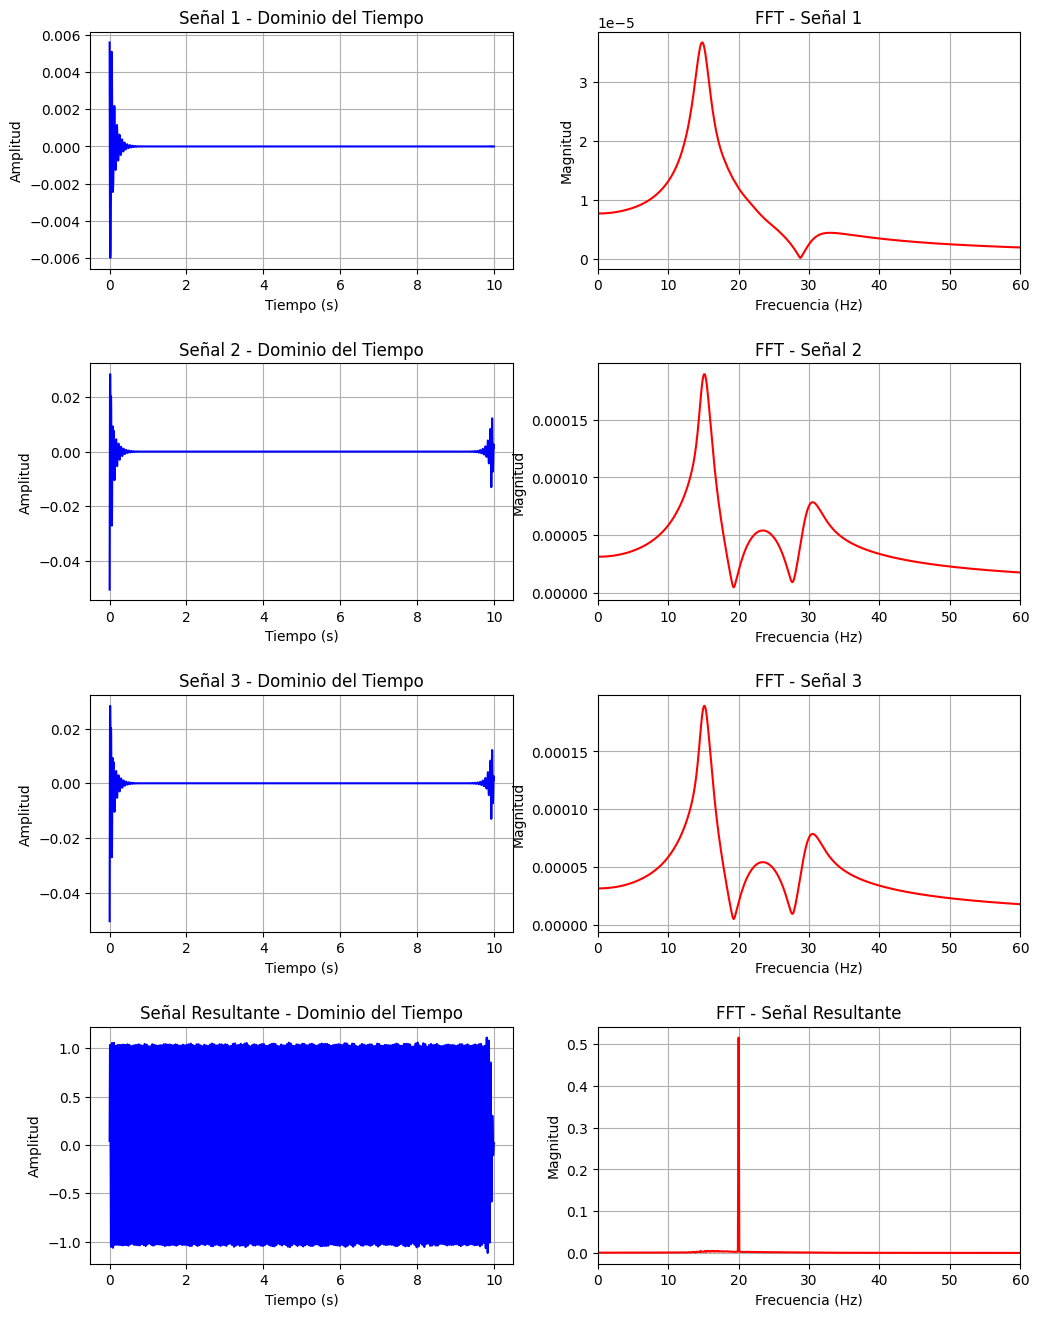

In [10]:
# --------------- Graficamos ------------------
import numpy as np
import matplotlib.pyplot as plt

# Lista de tus señales procesadas y sus nombres para el bucle
senales = [procesada1, procesada2, procesada3, procesadaResultante]
nombres = ["Señal 1", "Señal 2", "Señal 3", "Señal Resultante"]

# Configuración de la figura (4 filas, 2 columnas)
fig, ax = plt.subplots(4, 2, figsize=(12, 16))
fig.subplots_adjust(hspace=0.4)

for i, data in enumerate(senales):
    # --- 1. Plot en el Tiempo ---
    ax[i, 0].plot(t, data, color='blue')
    ax[i, 0].set_title(f"{nombres[i]} - Dominio del Tiempo")
    ax[i, 0].set_xlabel("Tiempo (s)")
    ax[i, 0].set_ylabel("Amplitud")
    ax[i, 0].grid(True)

    # --- 2. Cálculo de la FFT ---
    n = len(data)
    # Calculamos la FFT y obtenemos las magnitudes
    fft_values = np.fft.fft(data)
    fft_mag = np.abs(fft_values) / n  # Normalización

    # Obtener las frecuencias correspondientes
    freqs = np.fft.fftfreq(n, d=1/fs)

    # Solo nos interesa la mitad positiva del espectro
    half_n = n // 2

    # --- 3. Plot de la FFT ---
    ax[i, 1].plot(freqs[:half_n], fft_mag[:half_n], color='red')
    ax[i, 1].set_title(f"FFT - {nombres[i]}")
    ax[i, 1].set_xlabel("Frecuencia (Hz)")
    ax[i, 1].set_ylabel("Magnitud")
    ax[i, 1].set_xlim(0, 60)  # Zoom a la zona de interés (0-60Hz)
    ax[i, 1].grid(True)

plt.show()

### Caso Practico
Utilizando un ECG simulado se añaden la señal resultante y se filtra

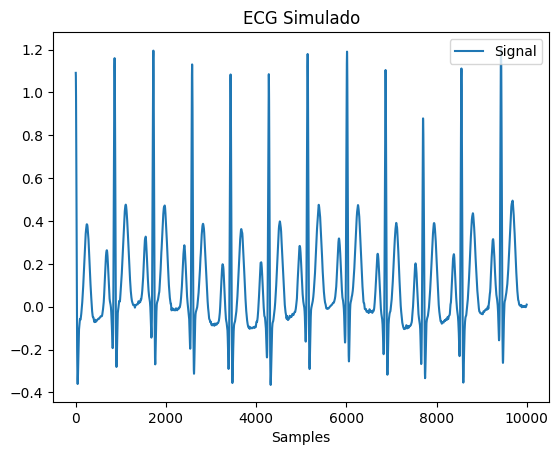

In [11]:
# ----------- Caso practico con ECG generado --------------------
# Generamos el ECG simulado con neurokit
import neurokit2 as nk
ecgS = nk.ecg_simulate(duration=10, sampling_rate=1000, heart_rate=70)

# Mostremos la señal simulada
nk.signal_plot(ecgS, title='ECG Simulado')


In [12]:
sigECG = ecgS + sigResul

# Usaremos la funcion en FIIR como la ayuda menciona
procesada = filtro_pasabanda_fir(sigECG, a, b, fs)


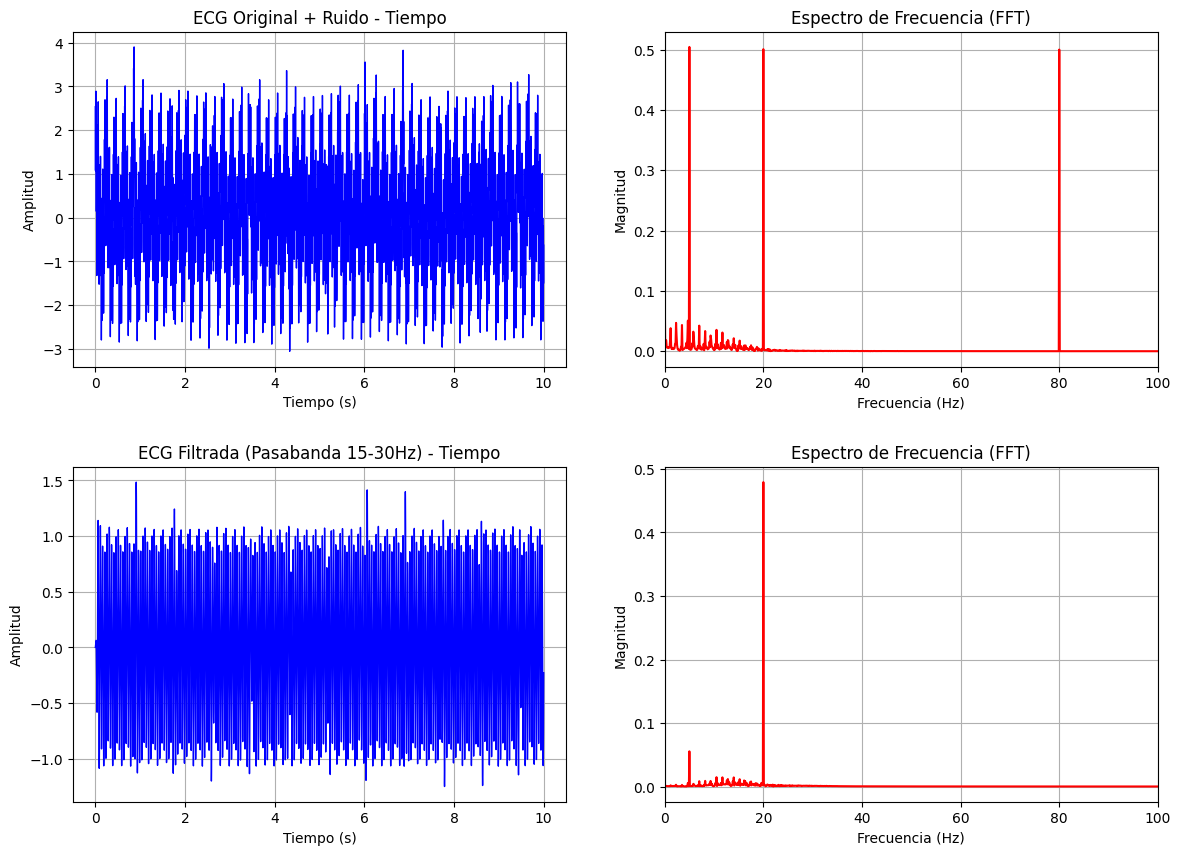

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Lista para iterar fácilmente: [Señal original, Señal filtrada]
datos_graficar = [sigECG, procesada]
titulos = ["ECG Original + Ruido", "ECG Filtrada (Pasabanda 15-30Hz)"]

# 2. Configurar la figura (2 filas, 2 columnas)
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.subplots_adjust(hspace=0.3, wspace=0.2)

for i, data in enumerate(datos_graficar):
    # --- PLOT EN EL TIEMPO (Columna 0) ---
    ax[i, 0].plot(t, data, color='blue', lw=1)
    ax[i, 0].set_title(f"{titulos[i]} - Tiempo")
    ax[i, 0].set_xlabel("Tiempo (s)")
    ax[i, 0].set_ylabel("Amplitud")
    ax[i, 0].grid(True)

    # --- CÁLCULO DE LA FFT ---
    n = len(data)
    fft_values = np.fft.fft(data)
    fft_mag = np.abs(fft_values) / n
    freqs = np.fft.fftfreq(n, d=1/fs)
    half_n = n // 2

    # --- PLOT DE LA FFT (Columna 1) ---
    ax[i, 1].plot(freqs[:half_n], fft_mag[:half_n], color='red')
    ax[i, 1].set_title(f"Espectro de Frecuencia (FFT)")
    ax[i, 1].set_xlabel("Frecuencia (Hz)")
    ax[i, 1].set_ylabel("Magnitud")
    ax[i, 1].set_xlim(0, 100)  # Ajustado a 100Hz para ver mejor el contexto
    ax[i, 1].grid(True)

plt.show()

# Ejercicio 2
##  Eliminación de Ruido Blanco
### Caso biomedico

Un sistema de telemedicina transmite señales ECG desde zonas rurales.
Las señales presentan ruido blanco debido al sistema electrónico y transmisión inalámbrica.

### Ayuda
```python
b, a = butter(N, wn, btype='low', fs=fs)

filtered = filtfilt(b, a, noisy)
```

### Actividad
Genere:
* ECG sintético
* ruido blanco
* interferencia de alta frecuencia

Diseñe:
* lowpass
* bandpass

In [14]:
# ------- Funcion de Ruido blanco -----------
import numpy as np
from scipy.signal import butter, filtfilt

def agregar_ruido_blanco(sig, nivel_ruido=0.1):
    """
    Añade ruido blanco gaussiano a una señal de entrada.

    input:
    - senal: Array numpy de la señal original.
    - nivel_ruido: Amplitud del ruido (desviación estándar).
                   A mayor valor, más fuerte será el ruido.

    output:
    - senal_ruidosa: La señal con el ruido superpuesto.
    - ruido: La señal de ruido pura.
    """
    # Convertir a numpy array por si entra como lista
    sig = np.array(sig)

    # Generar el ruido blanco (media 0, desviación estándar = nivel_ruido)
    ruido = np.random.normal(loc=0.0, scale=nivel_ruido, size=len(sig))

    # Sumar el ruido a la señal original
    sig_ruidosa = sig + ruido

    return sig_ruidosa, ruido

def agregar_interferencia_hf(sig, fs, freq_interferencia=60.0, amplitud=0.2):
    """
    Añade una interferencia de alta frecuencia (onda senoidal) a la señal.
    input:
      - sig: señal de entrada
      - fs: Frecuencia de muestreo en Hz
      - freq_interferencia: Frecuencia del ruido en Hz (ej. 50 o 60 para línea eléctrica)
      - amplitud: amplitud de la interferencia
    output:
      - sig_resultante: señal con interferencia
      - interferencia: señal interferencia
    """
    sig = np.array(sig)

    # Crear un vector de tiempo exacto para la longitud de la señal
    t = np.arange(len(sig)) / fs

    # Generar la onda de interferencia
    interferencia = amplitud * np.sin(2 * np.pi * freq_interferencia * t)

    # Sumar la interferencia a la señal
    sig_resultante = sig + interferencia

    return sig_resultante, interferencia


def aplicar_filtro(sig, fc, tipo="low", fs=1000.0, orden=5):
    """
    Aplica un filtro Butterworth digital a una señal.

    inputs:
      - sig: Señal de entrada.
      - fc: Frecuencia de corte principal en Hz.
      - tipo: 'low' (pasabajos) o 'high' (pasaaltas).
      - fs: Frecuencia de muestreo en Hz (por defecto 1000.0).
      - orden: Orden del filtro (por defecto 5).

    outputs:
      - senal_filtrada: Señal filtrada
    """

    # 1. Validar el tipo de filtro y la frecuencia de corte
    if tipo in ['low', 'high']:
        if fc is None or fc <= 0:
            raise ValueError(f"Para el filtro '{tipo}', la frecuencia de corte (fc) debe ser mayor a 0.")
        wn = fc  # Frecuencia de corte para Scipy

    else:
        raise ValueError("Tipo no válido. Usa exclusivamente 'low' o 'high'.")

    # 2. Generar los coeficientes del filtro
    coef_b, coef_a = butter(orden, wn, btype=tipo, fs=fs)

    # 3. Aplicar el filtro sin desfase temporal
    senal_filtrada = filtfilt(coef_b, coef_a, sig)

    return senal_filtrada

In [15]:
# Usaremos el ECG sintetico del anterior ejercicio -> ecgS

ecgN, noise = agregar_ruido_blanco(ecgS)

fs = 1000.0  # Asegúrate de usar tu frecuencia de muestreo real
ecg_final, _ = agregar_interferencia_hf(ecgN, fs, freq_interferencia=60.0, amplitud=0.5)

sig_filtrada_low = aplicar_filtro(ecg_final, fc=15, tipo="low", fs=fs, orden=6)
sig_filtrada_hig = aplicar_filtro(ecg_final, fc=60, tipo="high", fs=fs, orden=6)

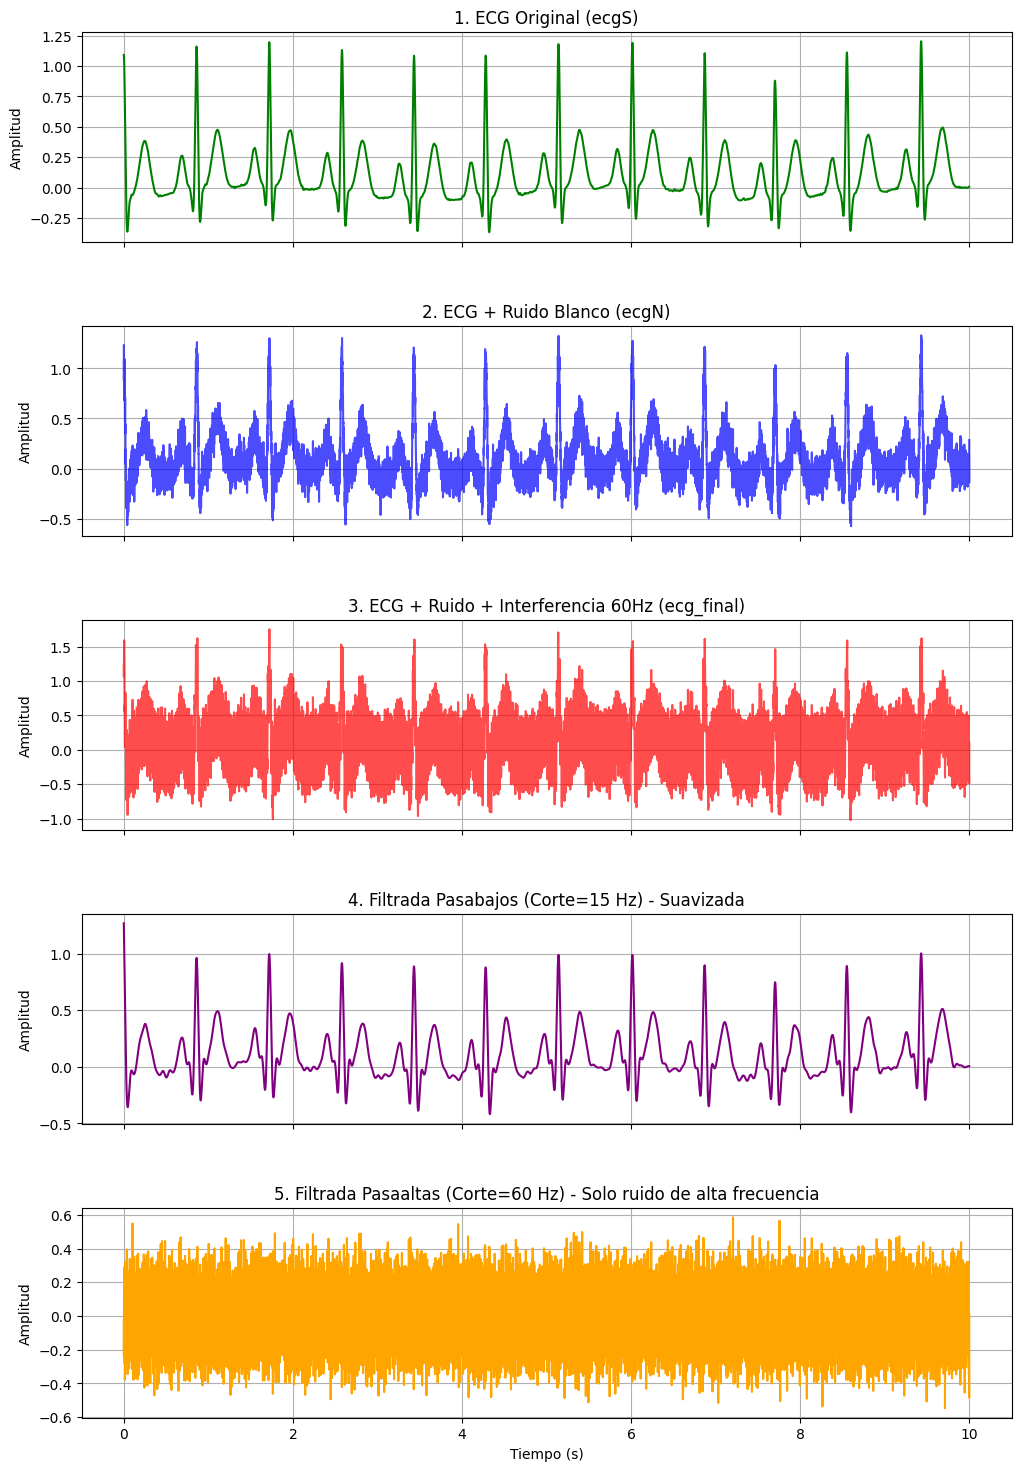

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Creamos el vector de tiempo basado en la longitud de tu señal
t = np.arange(len(ecgS)) / fs

# Configurar la figura (5 filas, 1 columna).
# sharex=True hace que todas las gráficas compartan el mismo eje X.
fig, ax = plt.subplots(5, 1, figsize=(12, 18), sharex=True)
fig.subplots_adjust(hspace=0.4)

# --- 1. ECG Original ---
ax[0].plot(t, ecgS, color='green')
ax[0].set_title("1. ECG Original (ecgS)")
ax[0].set_ylabel("Amplitud")
ax[0].grid(True)

# --- 2. ECG con Ruido Blanco ---
ax[1].plot(t, ecgN, color='blue', alpha=0.7)
ax[1].set_title("2. ECG + Ruido Blanco (ecgN)")
ax[1].set_ylabel("Amplitud")
ax[1].grid(True)

# --- 3. Señal Ruidosa Completa ---
ax[2].plot(t, ecg_final, color='red', alpha=0.7)
ax[2].set_title("3. ECG + Ruido + Interferencia 60Hz (ecg_final)")
ax[2].set_ylabel("Amplitud")
ax[2].grid(True)

# --- 4. Filtro Pasabajos (Corte en 15 Hz) ---
ax[3].plot(t, sig_filtrada_low, color='purple')
ax[3].set_title("4. Filtrada Pasabajos (Corte=15 Hz) - Suavizada")
ax[3].set_ylabel("Amplitud")
ax[3].grid(True)

# --- 5. Filtro Pasaaltas (Corte en 60 Hz) ---
ax[4].plot(t, sig_filtrada_hig, color='orange')
ax[4].set_title("5. Filtrada Pasaaltas (Corte=60 Hz) - Solo ruido de alta frecuencia")
ax[4].set_ylabel("Amplitud")
ax[4].set_xlabel("Tiempo (s)")
ax[4].grid(True)

plt.show()

# Actividad 3
##  Ruido Impulsivo
### Caso biomédico

Durante un registro EEG aparecen desconexiones instantáneas de
electrodos produciendo spikes abruptos.

### Ayuda
```python

signal[100] = 5
signal[300] = -4
signal[700] = 6
filtered = medfilt(signal, 5)
```

### Actividad
Genere:
* señal EEG simulada
* 10 spikes aleatorios

Compare:
* FIR lowpass
* filtro mediana
* Explique cuál funciona mejor.

Using default location ~/mne_data for sample...
Creating /root/mne_data
Fetching 1 file for the sample dataset ...


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-sample-data-processed.tar.gz' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 02m21s (1576.2 MB)


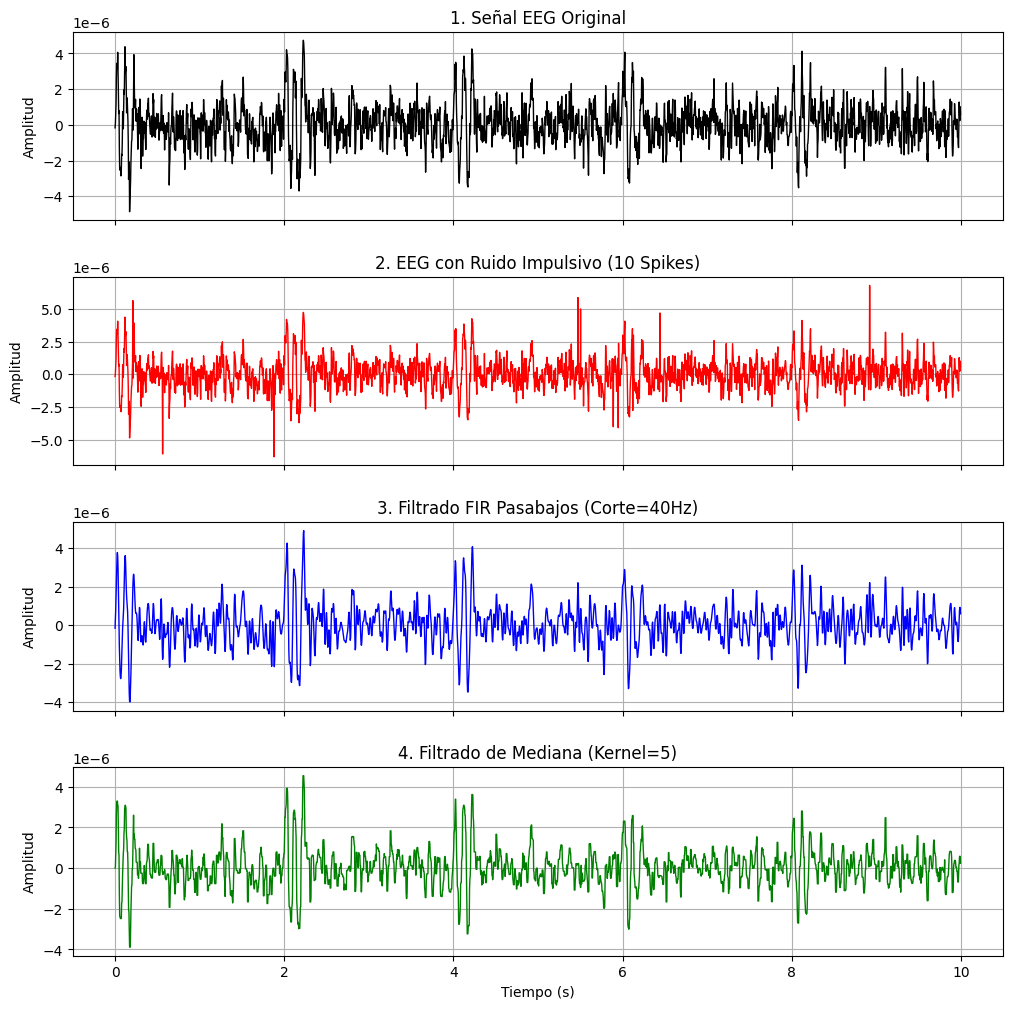

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt, firwin, filtfilt
import neurokit2 as nk

# --- 1. Definición de Funciones ---
def filtro_pasabaja_fir(data, fc, fs, numtaps=51):
    """
    Aplica un filtro FIR pasabajos usando el método de ventana.

    - data: Señal de entrada.
    - fc: Frecuencia de corte (Hz).
    - fs: Frecuencia de muestreo (Hz).
    - numtaps: Número de coeficientes (debe ser impar).
    """
    nyq = 0.5 * fs
    corte = fc / nyq
    # Diseño del filtro FIR
    fir_coeff = firwin(numtaps, corte)
    # filtfilt para evitar desfase
    y = filtfilt(fir_coeff, 1.0, data)
    return y

# --- 2. Parámetros y Simulación ---
fs = 256.0  # Frecuencia de muestreo típica para EEG
duracion = 10.0
t = np.linspace(0, duracion, int(duracion * fs), endpoint=False)

# Generar señal EEG limpia con neurokit2
eeg_limpio = nk.eeg_simulate(duration=duracion, sampling_rate=fs)

# --- 3. Inyección de Ruido Impulsivo ---
np.random.seed(42) # Para reproducibilidad en los spikes
eeg_ruidoso = eeg_limpio.copy()

# Generar 10 índices aleatorios (evitando los extremos)
indices_spikes = np.random.choice(np.arange(10, len(eeg_ruidoso) - 10), size=10, replace=False)
amplitud_spike = 5 * np.std(eeg_limpio) # Magnitud lo suficientemente grande para destacar

for idx in indices_spikes:
    signo = np.random.choice([-1, 1])
    eeg_ruidoso[idx] += signo * amplitud_spike

# --- 4. Filtrado ---
# A. Filtro FIR Pasa Bajas (Corte en 40Hz, típico en EEG)
eeg_filtrado_fir = filtro_pasabaja_fir(eeg_ruidoso, fc=40, fs=fs)

# B. Filtro Mediana (Kernel de 5 como indica la ayuda)
eeg_filtrado_mediana = medfilt(eeg_ruidoso, kernel_size=5)

# --- 5. Graficado (Estilo iterativo) ---
# Listas para iterar fácilmente
datos_graficar = [eeg_limpio, eeg_ruidoso, eeg_filtrado_fir, eeg_filtrado_mediana]
titulos = [
    "1. Señal EEG Original",
    "2. EEG con Ruido Impulsivo (10 Spikes)",
    "3. Filtrado FIR Pasabajos (Corte=40Hz)",
    "4. Filtrado de Mediana (Kernel=5)"
]
colores = ['black', 'red', 'blue', 'green']

# Configurar la figura (4 filas, 1 columna) compartiendo el eje X
fig, ax = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
fig.subplots_adjust(hspace=0.3)

for i, data in enumerate(datos_graficar):
    ax[i].plot(t, data, color=colores[i], lw=1)
    ax[i].set_title(titulos[i])
    ax[i].set_ylabel("Amplitud")
    ax[i].grid(True)

ax[3].set_xlabel("Tiempo (s)")
plt.show()

### Análisis: ¿Qué filtro funciona mejor para ruido impulsivo?

Para el caso de **desconexiones instantáneas** (ruido impulsivo o spikes abruptos), el **filtro de mediana** funciona significativamente mejor

* **Filtro de Mediana (No Lineal):** Al evaluar una pequeña ventana móvil (kernel=5), ordena los valores y escoge el del centro. Los *spikes* representan valores extremos (anómalos), por lo que siempre quedan en los bordes del ordenamiento y son descartados. Esto elimina el artefacto por completo **sin alterar la forma de las ondas EEG reales**.
* **Filtro FIR Pasa Bajas (Lineal):** Funciona mediante promedios ponderados (convolución). Al intentar filtrar un *spike* de gran energía, el filtro lo "difumina", creando una ondulación temporal ancha (*ringing artifact*). No elimina el ruido, sino que lo redistribuye, lo cual es peligroso en bioseñales porque puede confundirse con actividad fisiológica real.

# Ejercicio 4
## Interferencia Eléctrica 60 Hz
###Caso biomédico:
Un monitor ECG hospitalario presenta interferencia causada por la
red eléctrica.


### Ayuda
```python
b, a = iirnotch(60, 30, fs)
filtered = filtfilt(b, a, noisy)
```

### Actividad
Simule:
* ECG
* ruido 60 Hz
* ruido blanco

Diseñe un pipeline que elimine:
* interferencia eléctrica
* ruido de alta frecuenc

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import iirnotch, butter, filtfilt
import neurokit2 as nk

"""
En este caso usaremos una logica similar a lo propuesto en el ejercico 2
Cambiaremos algunos parametros para diferenciarlo
"""

'\nEn este caso usaremos una logica similar a lo propuesto en el ejercico 2\nCambiaremos algunos parametros para diferenciarlo\n'

In [23]:

# 1. Parámetros
fs = 1000.0
duration = 10.0
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

In [25]:
# 2. Generación de Señales
# ECG Sintético
ecg_clean = nk.ecg_simulate(duration=duration, sampling_rate=fs, heart_rate=70)

# Ruido 60 Hz (Red eléctrica)
ruido_60hz = 0.5 * np.sin(2 * np.pi * 60 * t)

# Ruido Blanco Gaussiano
np.random.seed(42)
ruido_blanco = np.random.normal(0, 0.2, len(t))

# Señal contaminada final
ecg_noisy = ecg_clean + ruido_60hz + ruido_blanco

In [26]:
# 3. Diseño del Pipeline de Filtrado
# Paso A: Filtro Notch para eliminar exactamente los 60 Hz
Q = 30.0 # Factor de calidad
b_notch, a_notch = iirnotch(60.0, Q, fs)
ecg_notch = filtfilt(b_notch, a_notch, ecg_noisy)

# Paso B: Filtro Lowpass para suavizar y eliminar el ruido blanco residual
# Frecuencia de corte en 40Hz suele ser estándar para monitoreo ECG
b_low, a_low = butter(4, 40.0 / (fs / 2), btype='low')
ecg_final = filtfilt(b_low, a_low, ecg_notch)

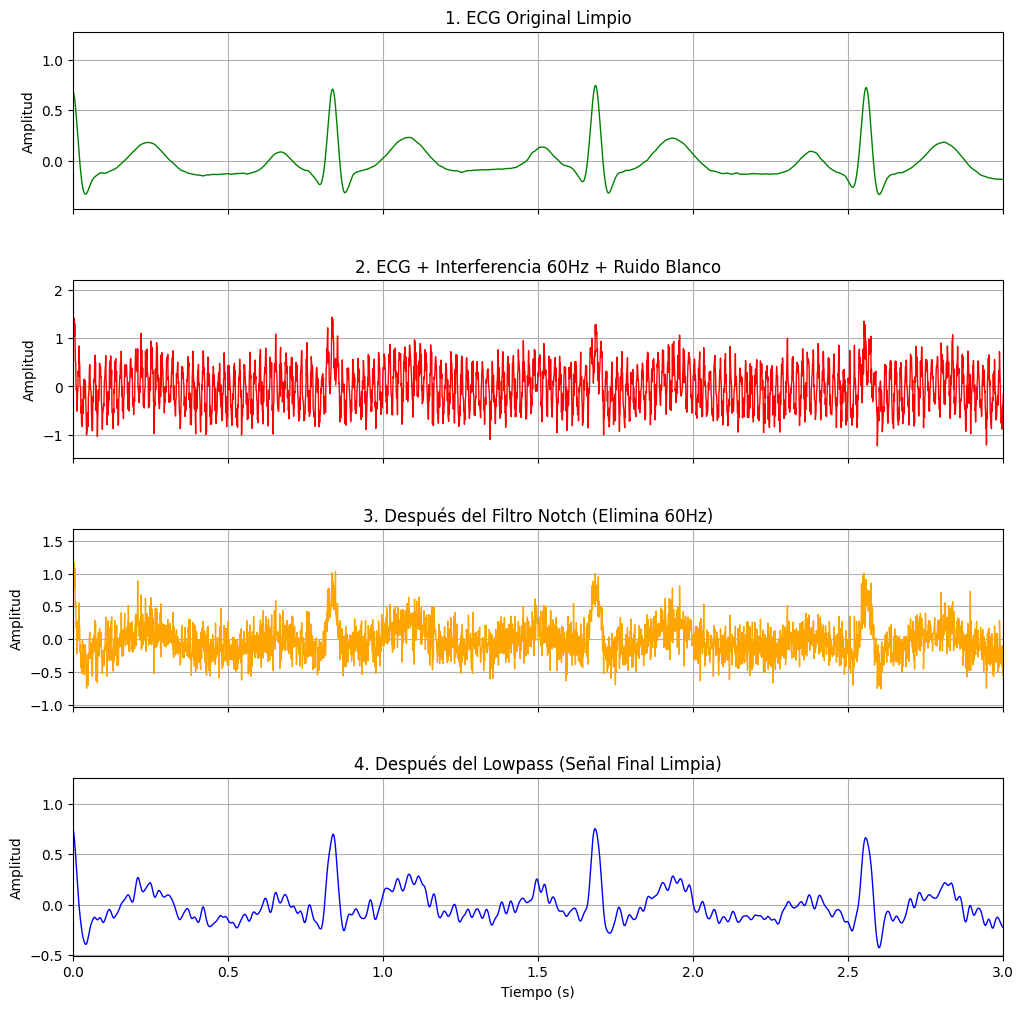

In [27]:

# 4. Gráficas
datos = [ecg_clean, ecg_noisy, ecg_notch, ecg_final]
titulos = [
    "1. ECG Original Limpio",
    "2. ECG + Interferencia 60Hz + Ruido Blanco",
    "3. Después del Filtro Notch (Elimina 60Hz)",
    "4. Después del Lowpass (Señal Final Limpia)"
]
colores = ['green', 'red', 'orange', 'blue']

fig, ax = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
fig.subplots_adjust(hspace=0.4)

for i, data in enumerate(datos):
    ax[i].plot(t, data, color=colores[i], lw=1)
    ax[i].set_title(titulos[i])
    ax[i].set_ylabel("Amplitud")
    ax[i].grid(True)

ax[3].set_xlabel("Tiempo (s)")
ax[3].set_xlim(0, 3) # Hacemos zoom a los primeros 3 segundos para ver el detalle
plt.show()

# Ejercicio 5
## Sensores Desincronizados
### Caso biomédico:
Un wearable biomédico utiliza:
* ECG
* respiración
* acelerómetro

Cada sensor inicia adquisición en tiempos distintos.

### Ayuda

```python
s2 = np.roll(s1, delay)
corr = correlate(s1, s2)
estimated_delay = np.argmax(corr) - len(s1)
print("Delay:", estimated_delay)
```

### Actividad
Genere:
* ECG
* respiración
* acelerómetro

Cada señal debe tener: delay distinto 2s y ruido gausiano.
Sincronice todas usando correlación cruzada

Delay estimado Respiración: 2.00 segundos
Delay estimado Acelerómetro: 1.20 segundos


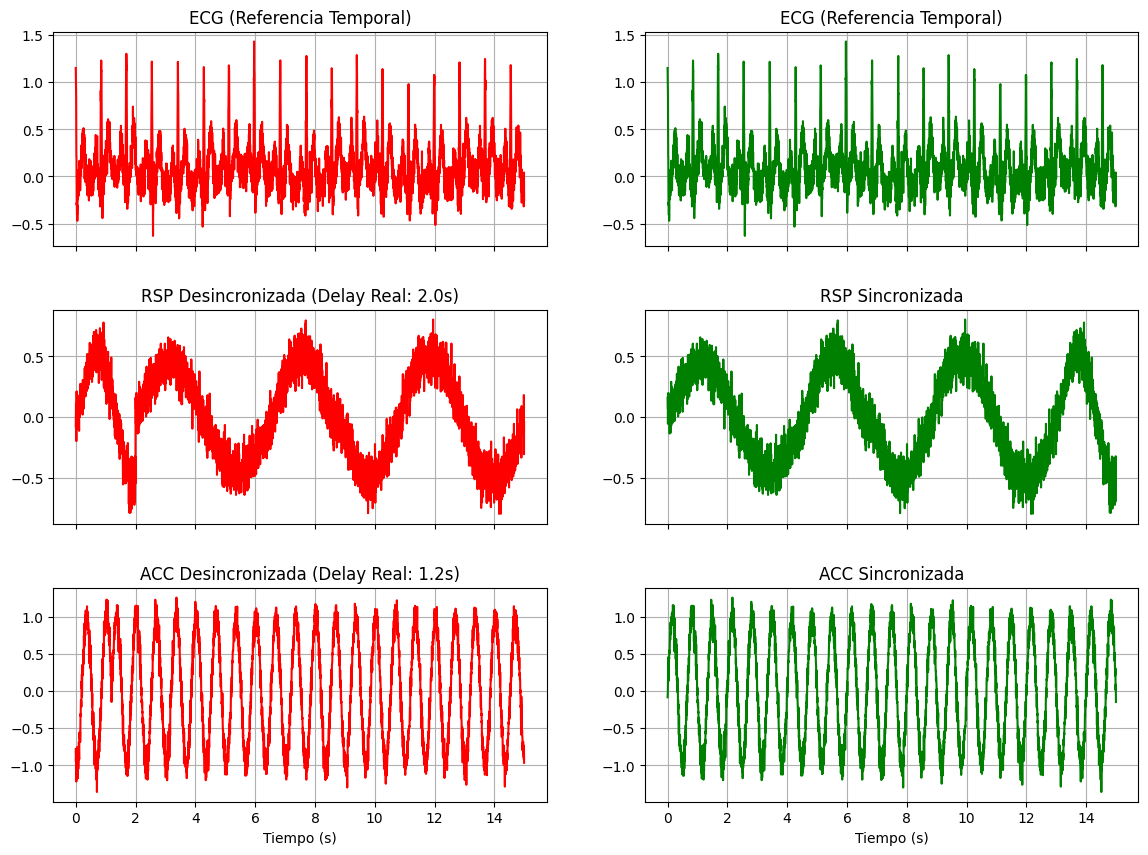

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate
import neurokit2 as nk

# 1. Parámetros base
fs = 250
duration = 15
t = np.linspace(0, duration, fs * duration, endpoint=False)

# 2. Generar Señales Limpias (Referencia temporal ideal)
ecg_ref = nk.ecg_simulate(duration=duration, sampling_rate=fs)
rsp_ref = nk.rsp_simulate(duration=duration, sampling_rate=fs)
# Simulamos un acelerómetro (movimiento periódico a 1.5 Hz)
acc_ref = np.sin(2 * np.pi * 1.5 * t)

# 3. Aplicar Delays y Ruido Gausiano
np.random.seed(42)
# Función auxiliar para desincronizar y ensuciar
def ensuciar_y_retrasar(senal, delay_segundos, fs):
    muestras_delay = int(delay_segundos * fs)
    senal_delay = np.roll(senal, muestras_delay)
    ruido = np.random.normal(0, 0.1, len(senal))
    return senal_delay + ruido

# Aplicamos distintos delays (ej. ECG 0s, RSP 2s, ACC 1.2s)
ecg_noisy = ensuciar_y_retrasar(ecg_ref, 0.0, fs)   # ECG es nuestra referencia (sin delay)
rsp_noisy = ensuciar_y_retrasar(rsp_ref, 2.0, fs)   # Delay de 2s
acc_noisy = ensuciar_y_retrasar(acc_ref, 1.2, fs)   # Delay de 1.2s

# 4. Sincronización por Correlación Cruzada
def sincronizar_senal(senal_sucia, senal_referencia):
    # Calcular correlación
    corr = correlate(senal_referencia, senal_sucia, mode='full')
    # Encontrar el retraso estimado (fórmula ajustada al índice de Python)
    estimated_delay = np.argmax(corr) - (len(senal_referencia) - 1)

    # Revertir el retraso usando roll hacia el lado contrario
    senal_sincronizada = np.roll(senal_sucia, estimated_delay)
    return senal_sincronizada, estimated_delay / fs

rsp_sync, delay_rsp = sincronizar_senal(rsp_noisy, rsp_ref)
acc_sync, delay_acc = sincronizar_senal(acc_noisy, acc_ref)

print(f"Delay estimado Respiración: {abs(delay_rsp):.2f} segundos")
print(f"Delay estimado Acelerómetro: {abs(delay_acc):.2f} segundos")

# 5. Gráficas Comparativas
fig, ax = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
fig.subplots_adjust(hspace=0.3)

# Columna 1: Desincronizado / Columna 2: Sincronizado
ax[0, 0].plot(t, ecg_noisy, color='red'); ax[0, 0].set_title("ECG (Referencia Temporal)")
ax[0, 1].plot(t, ecg_noisy, color='green'); ax[0, 1].set_title("ECG (Referencia Temporal)")

ax[1, 0].plot(t, rsp_noisy, color='red'); ax[1, 0].set_title(f"RSP Desincronizada (Delay Real: 2.0s)")
ax[1, 1].plot(t, rsp_sync, color='green'); ax[1, 1].set_title("RSP Sincronizada")

ax[2, 0].plot(t, acc_noisy, color='red'); ax[2, 0].set_title(f"ACC Desincronizada (Delay Real: 1.2s)")
ax[2, 1].plot(t, acc_sync, color='green'); ax[2, 1].set_title("ACC Sincronizada")
ax[2, 0].set_xlabel("Tiempo (s)"); ax[2, 1].set_xlabel("Tiempo (s)")

for axes in ax.flat:
    axes.grid(True)
plt.show()

# Ejercicio 6
## Resampling Multisensor
### Caso biomédico:
En una adquisición clínica:
* ECG se adquiere a 500 Hz
* respiración a 100 Hz
* temperatura a 200 Hz

Se requiere fusionar todas las señales

### Ejemplo
### Ayuda
```python
S2_resampled = resample(s2, len(s1))
```

### Actividad
Simule:
* ECG a 500 Hz
* respiración a 100 Hz
* acelerómetro a 200 Hz

Lleve todas las señales a:
  
>500 Hz y sincronícelas temporalmente.

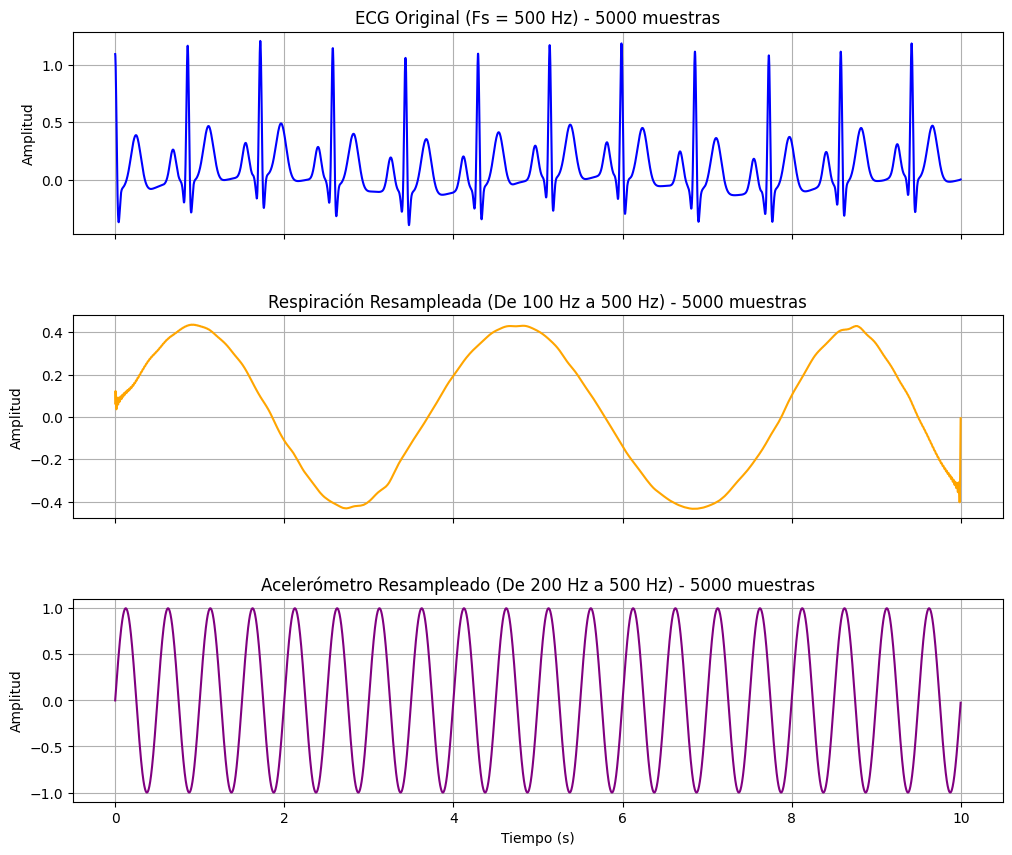

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample
import neurokit2 as nk

# 1. Parámetros de distintas frecuencias
# CORRECCIÓN: dur debe ser un número entero (int) para evitar errores en neurokit2
dur = 10
fs_ecg = 500
fs_rsp = 100
fs_acc = 200

# Vectores de tiempo independientes
t_ecg = np.linspace(0, dur, dur * fs_ecg, endpoint=False)
t_rsp = np.linspace(0, dur, dur * fs_rsp, endpoint=False)
t_acc = np.linspace(0, dur, dur * fs_acc, endpoint=False)

# 2. Simulación de Señales Multimodales
ecg = nk.ecg_simulate(duration=dur, sampling_rate=fs_ecg)
rsp = nk.rsp_simulate(duration=dur, sampling_rate=fs_rsp)
acc = np.sin(2 * np.pi * 2 * t_acc) # Acelerómetro simulado a 2 Hz

# 3. Resampling (Sobremuestreo / Upsampling a 500 Hz)
# La señal objetivo dicta la cantidad final de muestras: len(ecg)
muestras_objetivo = len(ecg)

rsp_resampled = resample(rsp, muestras_objetivo)
acc_resampled = resample(acc, muestras_objetivo)

# 4. Gráficas (Ahora todas comparten el vector de tiempo t_ecg de 500 Hz)
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.subplots_adjust(hspace=0.4)

ax[0].plot(t_ecg, ecg, color='blue')
ax[0].set_title(f"ECG Original (Fs = {fs_ecg} Hz) - {len(ecg)} muestras")

ax[1].plot(t_ecg, rsp_resampled, color='orange')
ax[1].set_title(f"Respiración Resampleada (De {fs_rsp} Hz a 500 Hz) - {len(rsp_resampled)} muestras")

ax[2].plot(t_ecg, acc_resampled, color='purple')
ax[2].set_title(f"Acelerómetro Resampleado (De {fs_acc} Hz a 500 Hz) - {len(acc_resampled)} muestras")
ax[2].set_xlabel("Tiempo (s)")

for axes in ax.flat:
    axes.grid(True)
    axes.set_ylabel("Amplitud")

plt.show()